In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

In [39]:
def add_entropy_to_results(results):
    probs = results['probs']
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    results['entropy'] = entropy
    results['neg_entropy'] = -entropy
    return results

def add_energy_to_results(results, T=1.0):
    logits = torch.from_numpy(results['logits'])
    energy = -T * torch.logsumexp(logits / T, dim=1).numpy()
    
    # flip sign so higher = more ID
    results['energy'] = -energy
    return results


def process_results(results):
    results['max_logit'] = np.max(results['logits'], axis=1)
    results['neg_mahal_distance'] = -results['mahal_distance']
    
    results = add_entropy_to_results(results)
    results = add_energy_to_results(results)
    
    return results

def compute_auroc_manual(id_results, ood_results, score_type):
    """
    Compute AUROC without plotting.

    Returns:
        auc_score (float)
    """
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]

    # Combine scores and get thresholds
    all_scores = np.concatenate([id_scores, ood_scores])
    thresholds = np.sort(np.unique(all_scores))[::-1]

    n_id = len(id_scores)
    n_ood = len(ood_scores)

    tpr = []
    fpr = []

    for t in thresholds:
        tp = np.sum(id_scores >= t)
        fp = np.sum(ood_scores >= t)

        tpr.append(tp / n_id)
        fpr.append(fp / n_ood)

    tpr = np.array(tpr)
    fpr = np.array(fpr)

    # Important: sort by FPR before integration
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    auc_score = np.trapz(tpr, fpr)

    return auc_score

In [40]:
data_name = "WISDM"
configs = [(1,1), (1,2), (2,1), (2,2), (3,2), (3,3)]

metrics = [
    "max_conf",
    "max_logit",
    "neg_entropy",
    "odin_score",
    "energy",
    "neg_mahal_distance"
]

all_results = {}
accuracy_results = {}
auroc_results = {}

for n, h in configs:
    key = f"n{n}_h{h}"
    
    # Special case
    suffix = "_v5" if (n, h) == (3, 2) else ""
    
    id_path = f"../analysis_results/{data_name}_n{n}_h{h}_id{suffix}.npz"
    ood_path = f"../analysis_results/{data_name}_n{n}_h{h}_ood{suffix}.npz"
    
    if not (os.path.exists(id_path) and os.path.exists(ood_path)):
        print(f"Skipping missing: {key}")
        continue
    
    # Load
    id_data = np.load(id_path)
    ood_data = np.load(ood_path)
    
    id_results = {k: id_data[k] for k in id_data.files}
    ood_results = {k: ood_data[k] for k in ood_data.files}
    
    # Process metrics
    id_results = process_results(id_results)
    ood_results = process_results(ood_results)
    
    all_results[key] = {"id": id_results, "ood": ood_results}
    
    # -------------------------
    # Accuracy
    # -------------------------
    id_acc = np.mean(id_results['targets'] == id_results['preds'])
    ood_acc = np.mean(ood_results['targets'] == ood_results['preds'])
    
    combined_targets = np.concatenate([id_results['targets'], ood_results['targets']])
    combined_preds   = np.concatenate([id_results['preds'], ood_results['preds']])
    combined_acc = np.mean(combined_targets == combined_preds)
    
    accuracy_results[key] = {
        "id_acc": id_acc,
        "ood_acc": ood_acc,
        "combined_acc": combined_acc
    }
    
    # -------------------------
    # AUROC
    # -------------------------
    auroc_results[key] = {}
    
    for metric in metrics:
        if metric not in id_results or metric not in ood_results:
            print(f"Skipping {metric} for {key}")
            continue
        
        auc = compute_auroc_manual(id_results, ood_results, metric)
        auroc_results[key][metric] = auc

In [41]:
final_results = {}

for key in accuracy_results:
    final_results[key] = {
        **accuracy_results[key],
        **auroc_results.get(key, {})
    }

df = pd.DataFrame.from_dict(final_results, orient="index")

In [42]:
df

,id_acc,ood_acc,combined_acc,max_conf,max_logit,neg_entropy,odin_score,energy,neg_mahal_distance
n1_h1,0.763598,0.0,0.445665,0.808485,0.804473,0.813808,0.803798,0.791227,0.625210
n1_h2,0.732218,0.0,0.427350,0.696754,0.655214,0.693374,0.647511,0.639483,0.615480
n2_h1,0.786611,0.0,0.459096,0.685490,0.684953,0.686696,0.673475,0.679674,0.699202
n2_h2,0.797071,0.0,0.465201,0.804286,0.774853,0.795967,0.772626,0.757405,0.785221
n3_h2,0.811715,0.0,0.473748,0.746304,0.701193,0.731757,0.738129,0.682695,0.861081
n3_h3,0.815900,0.0,0.476190,0.807660,0.744604,0.796804,0.713113,0.726616,0.849940


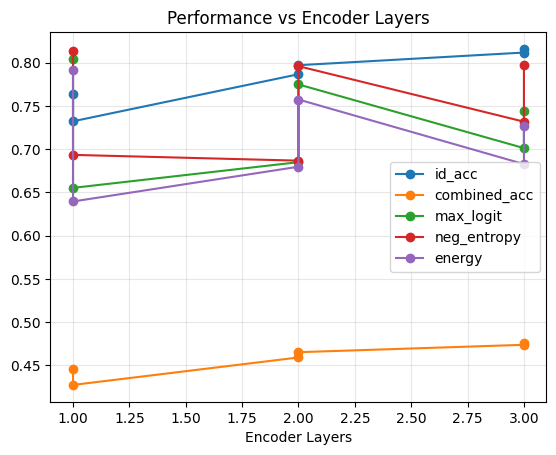

In [43]:
encoder_layers = []
attention_heads = []

df_plot = df.copy()
df_plot.index = df_plot.index.map(str).str.strip()

for idx in df_plot.index:
    s = str(idx)
    
    # extract numbers manually
    n = int(s.split("_")[0][1:])  # "n1" -> 1
    h = int(s.split("_")[1][1:])  # "h2" -> 2
    
    encoder_layers.append(n)
    attention_heads.append(h)

df_plot["encoder_layers"] = encoder_layers
df_plot["attention_heads"] = attention_heads


def plot_heat_scatter(df, value_col, title):
    plt.figure(figsize=(6,5))
    
    sc = plt.scatter(
        df["encoder_layers"], 
        df["attention_heads"], 
        c=df[value_col], 
        s=200
    )
    
    for i, txt in enumerate(df.index):
        plt.text(
            df["encoder_layers"][i] + 0.05, 
            df["attention_heads"][i] + 0.05, 
            txt, fontsize=8
        )
    
    plt.colorbar(sc, label=value_col)
    plt.xlabel("Encoder Layers")
    plt.ylabel("Attention Heads")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


for col in ["id_acc", "combined_acc", "max_logit", "neg_entropy", "energy"]:
    plt.plot(df_plot["encoder_layers"], df_plot[col], 'o-', label=col)

plt.xlabel("Encoder Layers")
plt.title("Performance vs Encoder Layers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

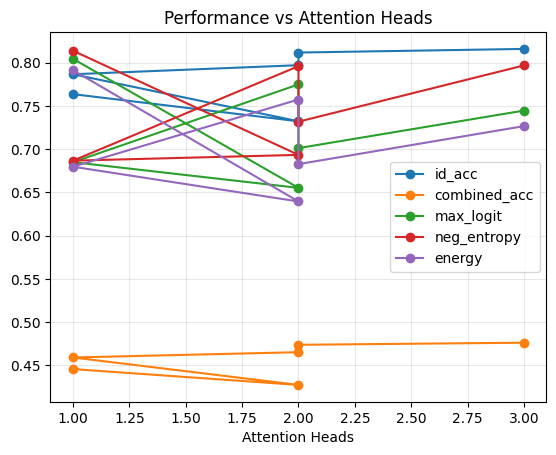

In [44]:
for col in ["id_acc", "combined_acc", "max_logit", "neg_entropy", "energy"]:
    plt.plot(df_plot["attention_heads"], df_plot[col], 'o-', label=col)

plt.xlabel("Attention Heads")
plt.title("Performance vs Attention Heads")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

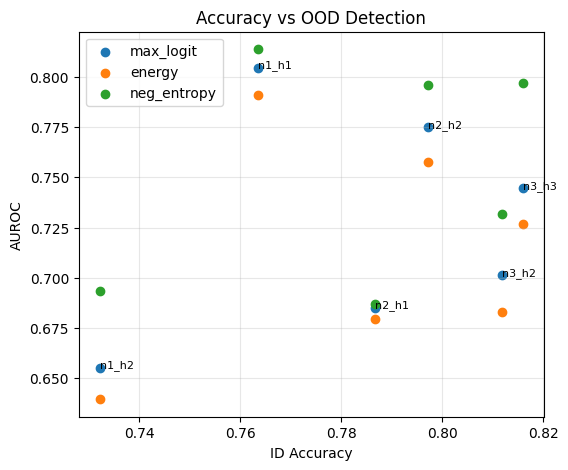

In [45]:
plt.figure(figsize=(6,5))

plt.scatter(df_plot["id_acc"], df_plot["max_logit"], label="max_logit")
plt.scatter(df_plot["id_acc"], df_plot["energy"], label="energy")
plt.scatter(df_plot["id_acc"], df_plot["neg_entropy"], label="neg_entropy")

for i, txt in enumerate(df_plot.index):
    plt.text(df_plot["id_acc"][i], df_plot["max_logit"][i], txt, fontsize=8)

plt.xlabel("ID Accuracy")
plt.ylabel("AUROC")
plt.title("Accuracy vs OOD Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

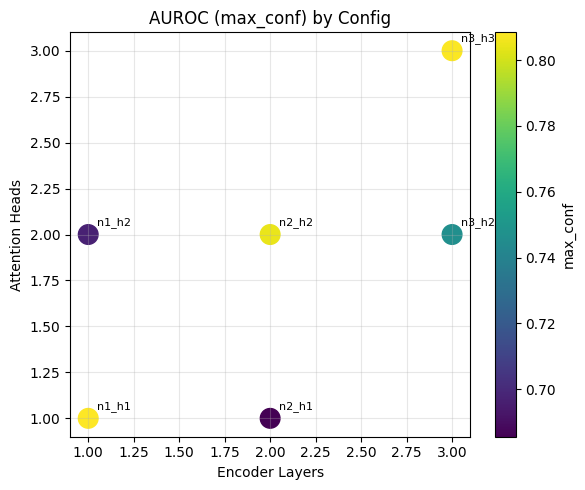

In [46]:
plot_heat_scatter(df_plot, "max_conf", "AUROC (max_conf) by Config")

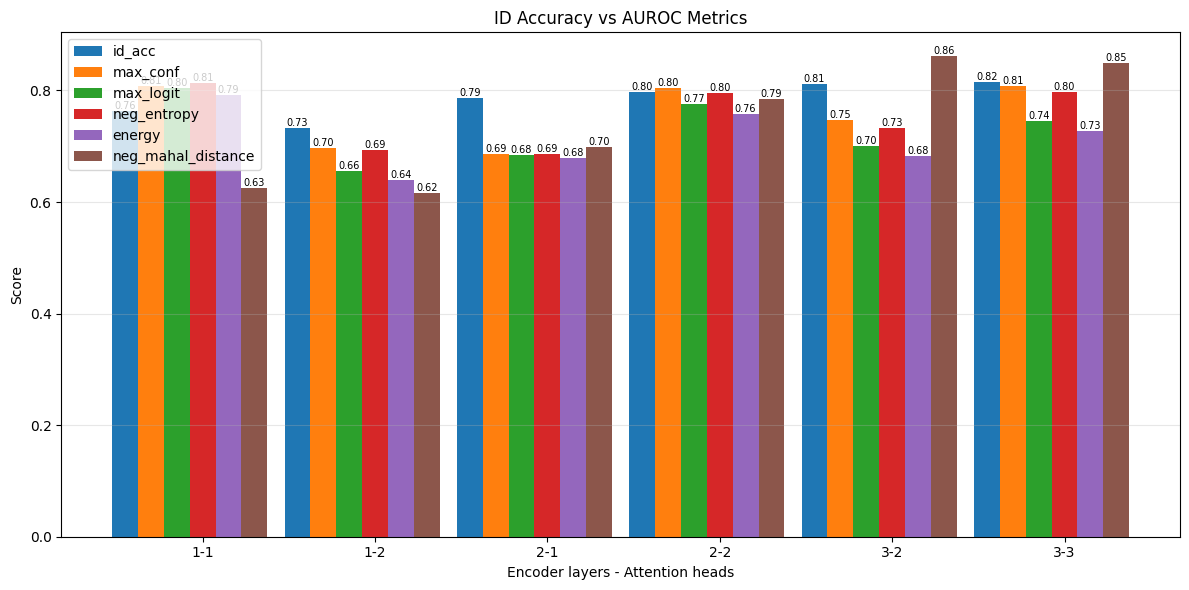

In [52]:
df_plot["config"] = (
    df_plot["encoder_layers"].astype(str) + "-" +
    df_plot["attention_heads"].astype(str)
)

metrics = ["id_acc", "max_conf", "max_logit", "neg_entropy", "energy", "neg_mahal_distance"]

x = np.arange(len(df_plot))
width = 0.15

plt.figure(figsize=(12,6))

for i, m in enumerate(metrics):
    bars = plt.bar(x + i * width, df_plot[m], width, label=m)

    # add value labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=0
        )

plt.xticks(
    x + width * (len(metrics) / 2),
    df_plot["config"]
)

plt.xlabel("Encoder layers - Attention heads")
plt.ylabel("Score")
plt.title("ID Accuracy vs AUROC Metrics")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()